# Goal 

Which model should the telecom company use if it wants an interpretable churn model, and what assumptions should it worry about before acting on the explanation?

In [1]:
%pip install kagglehub


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Download the dataset

In [2]:
import kagglehub

# Download the latest version of the Telco Customer Churn dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: /Users/ogechukwuezenwa/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [3]:
import pandas as pd
import os

# See what files were downloaded
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


## Explore and clean the dataset

In [4]:
# display the table
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# inspect the table to check for the number of columns and rows
print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

In [6]:
# check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# check for duplicated values
df.duplicated().sum()

np.int64(0)

In [8]:
# clean total charges and check for missing values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()

np.int64(11)

In [9]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
# remove the 11 missing rows
df = df.dropna(subset=["TotalCharges"])
df["TotalCharges"].isna().sum()

np.int64(0)

In [11]:
# verify the number of rows after cleaning
df["TotalCharges"].isna().sum()

np.int64(0)

In [12]:
# check for unique values since we have a lot of duplicated values
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str

gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen:
[0 1]

Partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

tenure:
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]

PhoneService:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<ArrowStringArray>
['D

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
# preparing churn - converting into integer datatype
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df["Churn"].dtype

dtype('int64')

In [15]:
df["Churn"].mean()

np.float64(0.26578498293515357)

## EDA for Linear Regression Assumptions

### Examine the balance of churn

In [16]:
# how balanced is the outcome
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [17]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

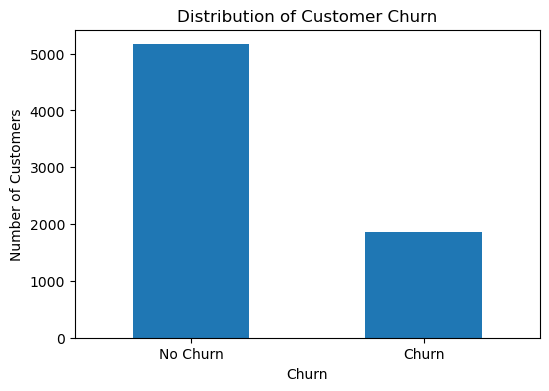

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

df["Churn"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Churn")
plt.xticks([0, 1], ["No Churn", "Churn"], rotation=0)

plt.show()

### Linearity

Linear regression assumes that the relationship between the predictors and outcome is approximately linear

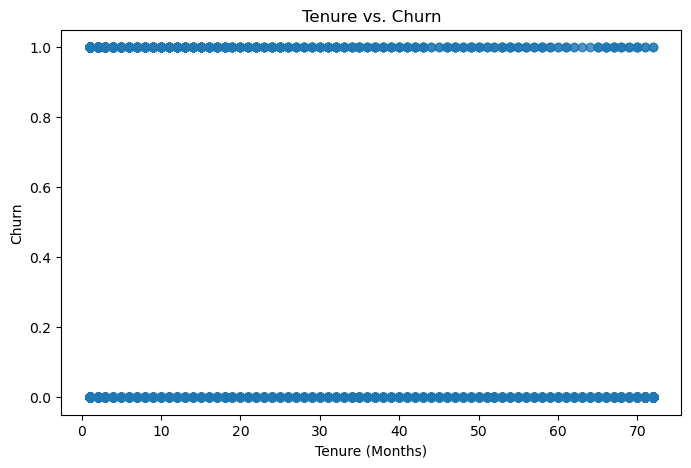

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(df["tenure"], df["Churn"], alpha=0.3)

plt.xlabel("Tenure (Months)")
plt.ylabel("Churn")
plt.title("Tenure vs. Churn")

plt.show()

This scatter isn't informative at all because churn is binary and all points are concentrated between 0 and 1

In [20]:
## Tenure vs Churn
df["tenure_bin"] = pd.cut(df["tenure"], bins=8)

tenure_churn = df.groupby("tenure_bin", observed=True)["Churn"].mean()

tenure_churn

tenure_bin
(0.929, 9.875]     0.500814
(9.875, 18.75]     0.330682
(18.75, 27.625]    0.237960
(27.625, 36.5]     0.214286
(36.5, 45.375]     0.197842
(45.375, 54.25]    0.164537
(54.25, 63.125]    0.109524
(63.125, 72.0]     0.063919
Name: Churn, dtype: float64

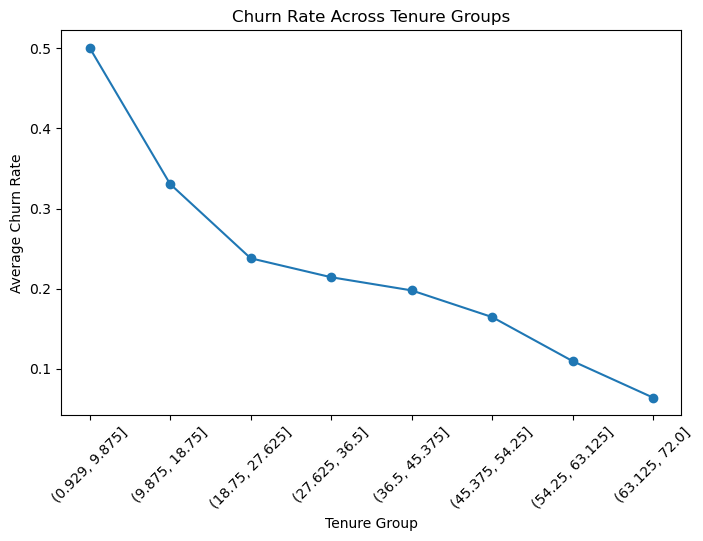

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(tenure_churn.index.astype(str), tenure_churn.values, marker="o")

plt.xlabel("Tenure Group")
plt.ylabel("Average Churn Rate")
plt.title("Churn Rate Across Tenure Groups")
plt.xticks(rotation=45)

plt.show()

The churn rate decreases as tenure increases. So there is a strong negative relationship between tenure and churn rate. The relationship appears to be non linear so I think linearity is violated. 

In [22]:
## Monthly Charges vs. Churn
df["MonthlyCharges_bin"] = pd.cut(df["MonthlyCharges"], bins=10)

monthly_churn = df.groupby("MonthlyCharges_bin", observed=True)["Churn"].mean()

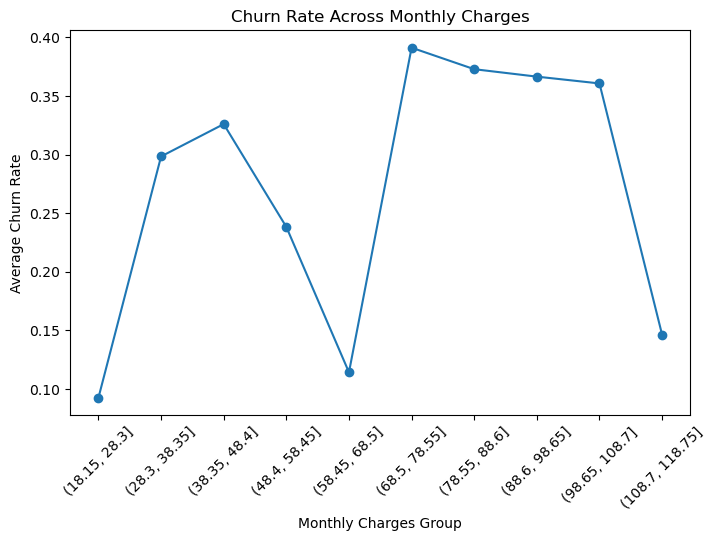

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(monthly_churn.index.astype(str), monthly_churn.values, marker="o")

plt.xlabel("Monthly Charges Group")
plt.ylabel("Average Churn Rate")
plt.title("Churn Rate Across Monthly Charges")

plt.xticks(rotation=45)

plt.show()

Linearity is violated

### Categorical predictors

In [24]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index")

contract_churn

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


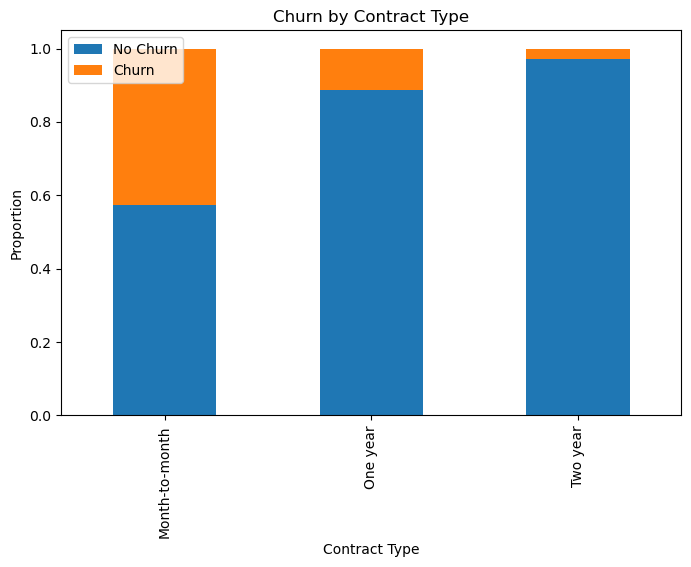

In [25]:
contract_churn.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.xlabel("Contract Type")
plt.ylabel("Proportion")
plt.title("Churn by Contract Type")
plt.legend(["No Churn", "Churn"])

plt.show()

Based on this plot contract can be said to be a meaningful predictor of churn

### Multicollinearity

In [26]:
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


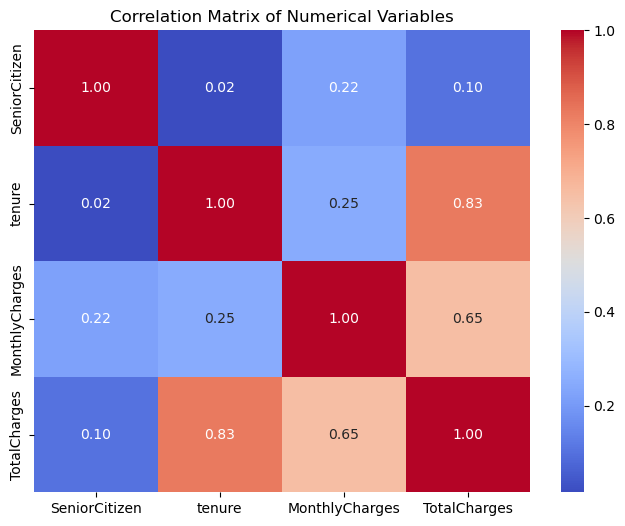

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

Correlations that is close to 0 suggest little linear relationship.
Correlations near +1 or −1 suggest potential multicollinearity.
Based on the heatmap, I make this interpretation

TotalCharges may be strongly related to tenure because total charges accumulate over time.
TotalCharges may also be related to MonthlyCharges, since it is broadly influenced by monthly charges and length of service.
SeniorCitizen is binary, so Pearson correlation provides only a rough indication of its association with the other variables.

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[numeric_cols].copy()

# Ensure all values are numeric and remove missing rows
X = X.apply(pd.to_numeric, errors="coerce").dropna()

vif_data = pd.DataFrame(
    {
        "Variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    }
)

vif_data

,Variable,VIF
0,SeniorCitizen,1.257569
1,tenure,6.332737
2,MonthlyCharges,3.701617
3,TotalCharges,8.085198


Based on VIF values, multicollinearity may be present primarily between tenure and TotalCharges, and this will be taken into consideration when developing the model

### Independence of observations

In [29]:
df["customerID"].duplicated().sum()

np.int64(0)

The independence assumption requires that each observation represents a separate customer and that observations are not dependent on one another. Since there is no duplicated customer ID it is safe to assume that the observations are independent but I could be wrong.

In [30]:
# Check how Churn is currently coded
print(df["Churn"].unique())
print(df["Churn"].dtype)

[0 1]
int64


## Runing Linear Regression Model

For running this linear regression model, I one-hot coded the categorical variales and dropped some predictors that resulted in structural differences

In [31]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Create modeling dataset
model_df = df.copy()

# Convert TotalCharges to numeric
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")

# Remove missing values
model_df = model_df.dropna()

# Remove ID and EDA-only variables
model_df = model_df.drop(columns=["customerID", "tenure_bin", "MonthlyCharges_bin"])

# Remove variables that create structural redundancy
# with InternetService
model_df = model_df.drop(
    columns=[
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "PhoneService",
    ]
)

# Define target
y = model_df["Churn"].astype(float)

# Define predictors
X = model_df.drop(columns=["Churn"])

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Ensure numeric
X = X.astype(float)

# Add intercept
X = sm.add_constant(X)

# Check rank
print("Number of predictors:", X.shape[1])
print("Matrix rank:", np.linalg.matrix_rank(X))

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

Number of predictors: 18
Matrix rank: 18
                            OLS Regression Results                            
Dep. Variable:                  Churn   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     157.0
Date:                Mon, 31 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:57:36   Log-Likelihood:                -3098.8
No. Observations:                7032   AIC:                             6234.
Df Residuals:                    7014   BIC:                             6357.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [32]:
print("Number of predictors:", X.shape[1])
print("Matrix rank:", np.linalg.matrix_rank(X))

Number of predictors: 18
Matrix rank: 18


In [33]:
# Display the complete coefficient table
results = pd.DataFrame(
    {
        "Coefficient": model.params,
        "Std Error": model.bse,
        "t-statistic": model.tvalues,
        "p-value": model.pvalues,
    }
)

results

,Coefficient,Std Error,t-statistic,p-value
const,0.202122,0.038658,5.228413,1.759112e-07
SeniorCitizen,0.051423,0.013034,3.945271,8.048751e-05
tenure,-0.001799,0.000503,-3.576710,3.502903e-04
MonthlyCharges,0.002224,0.000627,3.545714,3.941041e-04
TotalCharges,-0.000053,0.000006,-8.225157,2.303345e-16
gender_Male,-0.001880,0.008984,-0.209268,8.342450e-01
Partner_Yes,0.000418,0.010860,0.038524,9.692711e-01
Dependents_Yes,-0.023025,0.011521,-1.998480,4.570313e-02
MultipleLines_No phone service,0.084402,0.020468,4.123666,3.771929e-05
MultipleLines_Yes,0.047577,0.011288,4.214892,2.530340e-05


In [34]:
# Significant predictors at alpha = 0.05
results[results["p-value"] < 0.05].sort_values("p-value")

,Coefficient,Std Error,t-statistic,p-value
InternetService_Fiber optic,0.157580,0.018849,8.360203,7.480045e-17
TotalCharges,-0.000053,0.000006,-8.225157,2.303345e-16
Contract_One year,-0.115005,0.013998,-8.215790,2.488608e-16
PaymentMethod_Electronic check,0.079034,0.013294,5.945264,2.892547e-09
Contract_Two year,-0.088436,0.016887,-5.236986,1.679667e-07
const,0.202122,0.038658,5.228413,1.759112e-07
PaperlessBilling_Yes,0.051838,0.010000,5.183817,2.234637e-07
MultipleLines_Yes,0.047577,0.011288,4.214892,2.530340e-05
MultipleLines_No phone service,0.084402,0.020468,4.123666,3.771929e-05
SeniorCitizen,0.051423,0.013034,3.945271,8.048751e-05


In [35]:
print("Model Performance")
print("------------------")
print(f"R²:              {model.rsquared:.3f}")
print(f"Adjusted R²:     {model.rsquared_adj:.3f}")
print(f"F-statistic:     {model.fvalue:.1f}")
print(f"F-test p-value:  {model.f_pvalue:.3e}")
print(f"Observations (n): {int(model.nobs):,}")

Model Performance
------------------
R²:              0.276
Adjusted R²:     0.274
F-statistic:     157.0
F-test p-value:  0.000e+00
Observations (n): 7,032


An ordinary least squares (OLS) linear regression model was fitted to examine the relationship between customer characteristics and churn. The binary Churn variable was coded as 0 for customers who did not churn and 1 for customers who churned. Numerical variables were retained as continuous predictors, while categorical variables were one-hot encoded using a reference category. customerID and the binned variables created during exploratory analysis were excluded from the model.

After removing observations with missing values, the final dataset contained 7,032 observations. The resulting model contained 17 predictors plus an intercept, and the design matrix was full rank, indicating that the predictors did not contain exact linear dependencies.